In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp

print(mssfp.__version__)

0.0.5


In [2]:
mode = deepssfp.DataMode.SyntheticBanding.value
model_name = "block_phantom"
model_dir = "D:/DeepSSFP/"
path = os.path.join(model_dir, f"{model_name}_{mode.lower().replace(':', '_')}")
ds_path = os.path.join(model_dir, f"{model_name}_dataset.npy")
print(path, ds_path)

D:/DeepSSFP/block_phantom_syntheticbanding D:/DeepSSFP/block_phantom_dataset.npy


Saved dataset found. Loading from file: D:/DeepSSFP/block_phantom_dataset.npy


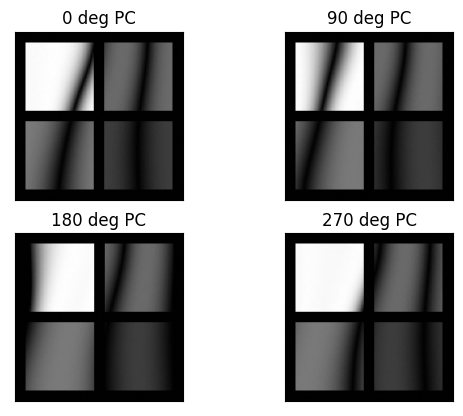

Using same scaler for SyntheticBanding mode
(160, 128, 128, 4) (160, 128, 128, 4)
-0.007850567144167825 0.09967612561713206 -0.007850567144167825 0.09967612561713206
Selected indices: [35  4  8]
Figure size: (8, 6)


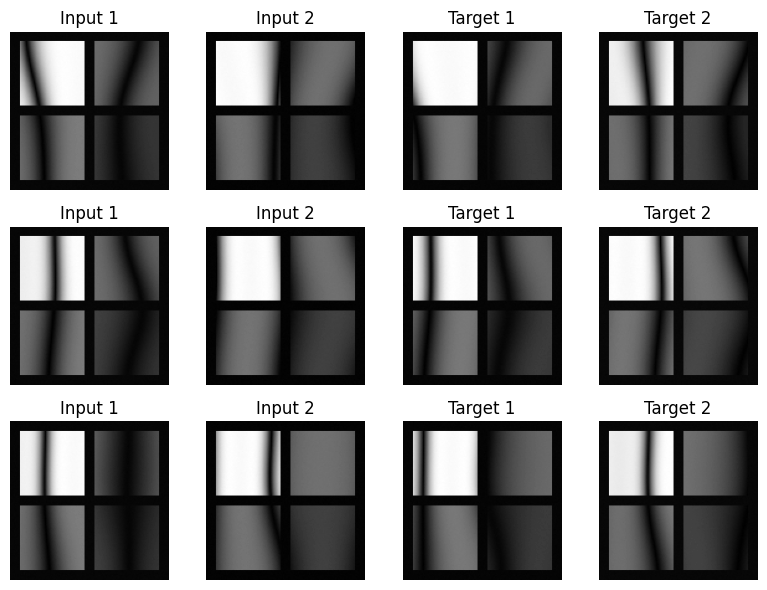

In [3]:
if(os.path.isfile(ds_path)):
    print(f'Saved dataset found. Loading from file: {ds_path}')
    dataset = np.load(ds_path, allow_pickle=True)[0]
else:
    slices = 200
    dataset = mssfp.generate_ssfp_dataset(phantom_type='block', slices=slices, shape=128, ids=[1, 2, 3, 4],
                                          npcs=4, f=500, alpha=np.deg2rad(60), sigma=0.001, data_indices=[(0, 2), (120,180)], 
                                          useRotate=True, useDeform=True)
    np.save(ds_path, [dataset])

data = dataset['M']
data.shape
mssfp.plot_dataset(data, slice=0)
ds = deepssfp.dataset.Dataset(mode, input_data=data)
print(ds.x_train.shape, ds.y_train.shape)
print(ds.inputScaler.mean, ds.inputScaler.std, ds.outputScaler.mean, ds.outputScaler.std)

deepssfp.visualize_images(
    input_images=ds.x_test,
    target_images=ds.y_test,
    num_samples=3
)

In [5]:
# Basic training
model, history, ds, predictions = deepssfp.train(
    mode=mode,
    model_name=model_name,
    model_dir=model_dir,
    custom_dataset=ds,
    epochs=400,
    use_early_stopping=False,
    patience=200,
    continue_training=True
)

2025-03-21 19:57:30,503 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/block_phantom_syntheticbanding
2025-03-21 19:57:30,504 - DeepSSFP - INFO - Training DataSet: (160, 128, 128, 4) | (160, 128, 128, 4)
2025-03-21 19:57:30,504 - DeepSSFP - INFO - Test DataSet: (40, 128, 128, 4) | (40, 128, 128, 4)
2025-03-21 19:57:31,094 - DeepSSFP - INFO - Loading existing model from D:/DeepSSFP/block_phantom_syntheticbanding.keras
2025-03-21 19:57:33,638 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/block_phantom_syntheticbanding_history.npz
2025-03-21 19:57:33,682 - DeepSSFP - INFO - Continuing training from epoch 400


Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 128, 128, 4) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 128, 128, 32) 1184        img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 128, 128, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 128, 128, 32) 128         conv2d_1[0][0]                   
______________________________________________________________________________________________

2025-03-21 19:57:34,266 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/block_phantom_syntheticbanding.keras


2/2 [==============================] - 4s 389ms/step - loss: 2.8787e-04 - mean_absolute_error: 0.0127


2025-03-21 19:57:38,242 - DeepSSFP - INFO - Training Complete. Loss: 0.0003, MAE: 0.0127
2025-03-21 19:57:38,243 - DeepSSFP - INFO - Time Elapsed: 4.55 seconds


2025-03-24 17:27:06,515 - DeepSSFP - INFO - Loading model from path: D:/DeepSSFP/block_phantom_syntheticbanding
2025-03-24 17:27:09,329 - DeepSSFP - INFO - Model loaded successfully from D:/DeepSSFP/block_phantom_syntheticbanding.keras
2025-03-24 17:27:09,330 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/block_phantom_syntheticbanding_history.npz
2025-03-24 17:27:10,331 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/block_phantom_syntheticbanding_training_history.png


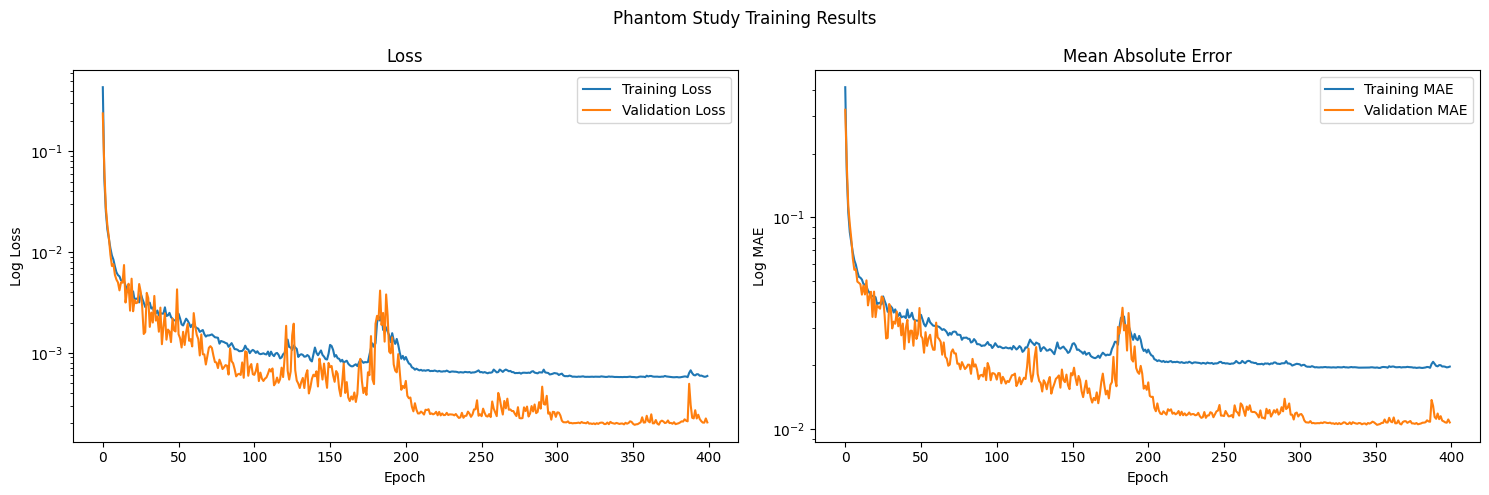

In [4]:
model, history_dict = deepssfp.load_model(
    mode=mode,
    model_name=model_name,
    model_dir=model_dir
)

deepssfp.plot_training_history(
    history_dict,
    title="Phantom Study Training Results",
    save_path=f"{path}_training_history.png"
)

In [5]:
ds = deepssfp.Dataset(mode, input_data=data)
x_test = ds.inputScaler.inverse_transform(ds.x_test)
y_test = ds.outputScaler.inverse_transform(ds.y_test)
predictions = ds.inputScaler.inverse_transform(deepssfp.predict(model, ds.x_test))

Using same scaler for SyntheticBanding mode


2025-03-24 17:27:14,289 - DeepSSFP - INFO - Making predictions on data with shape (40, 128, 128, 4)
2025-03-24 17:27:18,406 - DeepSSFP - INFO - Predictions complete. Output shape: (40, 128, 128, 4)


(40, 128, 128, 4) float32
(40, 128, 128, 4) (40, 128, 128, 4) float64 float64
Figure size: (12, 2)
Image visualization saved to D:/DeepSSFP/block_phantom_syntheticbanding_prediction_results.png


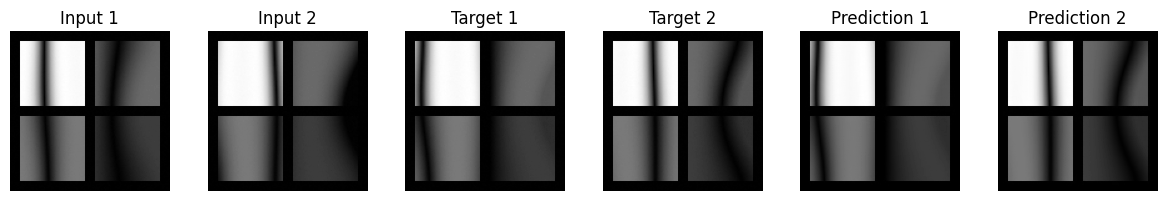

In [6]:
print(predictions.shape, predictions.dtype)
print(x_test.shape, y_test.shape, x_test.dtype, y_test.dtype)
deepssfp.visualize_images([0], x_test, y_test, predictions, save_path=f"{path}_prediction_results.png")

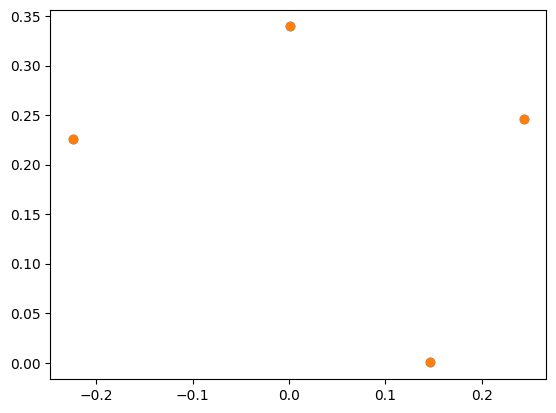

In [19]:
target = deepssfp.combine_synthetic_banding_datasets(x_test, y_test)
target = deepssfp.from_pairs_to_complex(target)
id = 1
mask = (dataset['seg'] == id)
t = target[0,mask,:]

pred = deepssfp.combine_synthetic_banding_datasets(x_test, predictions)
pred = deepssfp.from_pairs_to_complex(pred)
mask = (dataset['seg'] == id)
p = target[0,mask,:]

idx = 100
plt.scatter(np.real(t[idx,:]), np.imag(t[idx,:]))
plt.scatter(np.real(p[idx,:]), np.imag(p[idx,:]))

plt.show()

real/imag pairs -> complex
real/imag pairs -> complex
(40, 128, 128, 8) (40, 128, 128) (40, 128, 128)
Selected indices: [14]
Figure size: (12, 2)


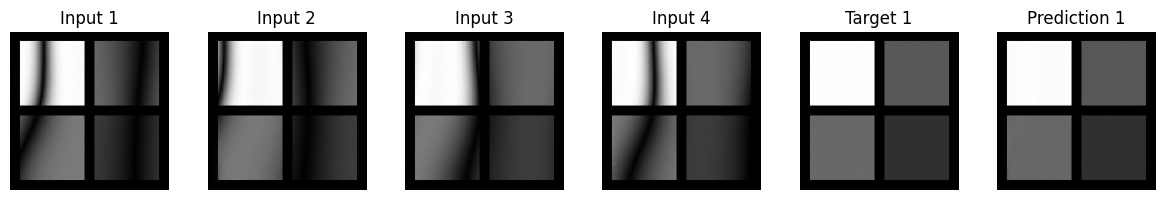

In [9]:
import deepssfp.recon
target = deepssfp.combine_synthetic_banding_datasets(x_test, y_test)
target = deepssfp.recon.gs_recon_3d(target)

combine = deepssfp.combine_synthetic_banding_datasets(x_test, predictions)
pred = deepssfp.recon.gs_recon_3d(combine)
print(combine.shape, target.shape, pred.shape)

deepssfp.visualize_images(
    input_images=combine,
    target_images=target,
    predicted_images=pred
)

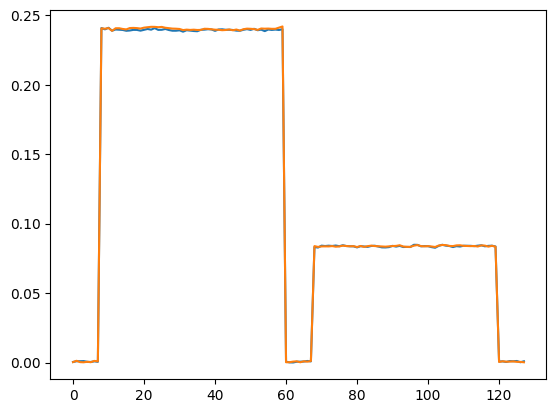

In [10]:
plt.plot(np.abs(target[0,20,:]))
plt.plot(np.abs(pred[0,20,:]))
plt.show()

Target shape: (40, 128, 128)
Prediction shape: (40, 128, 128)
Segmentation shape: (128, 128)
Unique segmentation IDs: [0. 1. 2. 3. 4.]
IDs to plot: [1. 2. 3. 4.]
Training history plot saved to D:/DeepSSFP/block_phantom_syntheticbanding_metrics_scatter


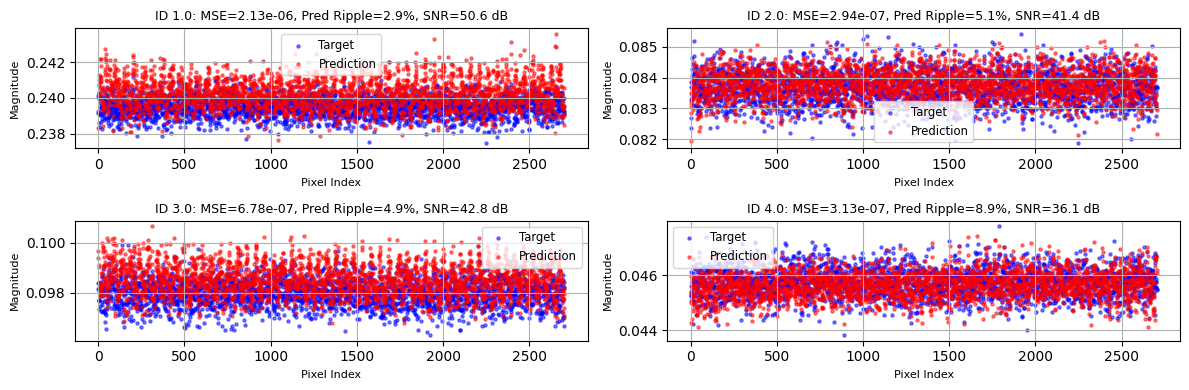

Training history plot saved to D:/DeepSSFP/block_phantom_syntheticbanding_metrics


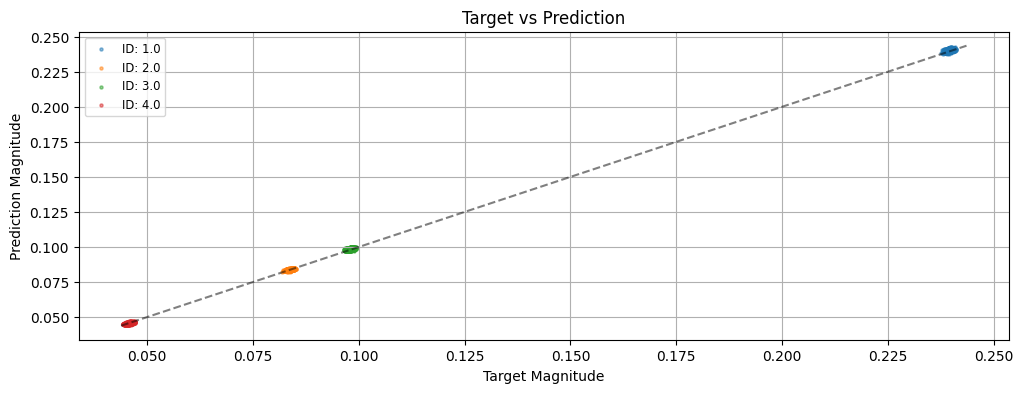


Metrics by Segment ID (averaged across all samples):
ID 1.0: MSE=2.13e-06, MAE=1.14e-03, Pred Min=0.2374, Pred Max=0.2443, Pred Ripple=2.86%, Pred SNR=50.6 dB, Target Min=0.2374, Target Max=0.2415, Target Ripple=1.69%, Target SNR=50.4 dB, Samples=40, Pixels=2704
ID 2.0: MSE=2.94e-07, MAE=4.14e-04, Pred Min=0.0817, Pred Max=0.0860, Pred Ripple=5.10%, Pred SNR=41.4 dB, Target Min=0.0818, Target Max=0.0854, Target Ripple=4.33%, Target SNR=41.3 dB, Samples=40, Pixels=2704
ID 3.0: MSE=6.78e-07, MAE=6.47e-04, Pred Min=0.0961, Pred Max=0.1009, Pred Ripple=4.91%, Pred SNR=42.8 dB, Target Min=0.0961, Target Max=0.0997, Target Ripple=3.74%, Target SNR=42.7 dB, Samples=40, Pixels=2704
ID 4.0: MSE=3.13e-07, MAE=4.32e-04, Pred Min=0.0439, Pred Max=0.0479, Pred Ripple=8.85%, Pred SNR=36.1 dB, Target Min=0.0439, Target Max=0.0475, Target Ripple=7.77%, Target SNR=36.1 dB, Samples=40, Pixels=2704
{1.0: {'mse': 2.1302199845417377e-06, 'mae': 0.0011427707041053088, 'pred_min': 0.2374239808639227, 'pred_

In [11]:
metrics = deepssfp.evaluate_band_reduction(target, pred, dataset['seg'], sort_values=False, fig_size=(6, 2), save_path=f"{path}_metrics")
print(metrics)